# Applying machine learning models( Decision tree,Random forest ,KNN) to identify Lymphoma disease(text/image)

Importing and selecting zip file.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


Unzipping the zipped file.

In [26]:
import zipfile
import os

zip_path = "archive (2).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

Checking structure

In [4]:
os.listdir("/content/dataset")

['Original_dataset']

Category extraction.

In [27]:
import cv2
import numpy as np

data = []
labels = []

dataset_path = "/content/dataset/Original_dataset"
categories = os.listdir(dataset_path)   # automatically detect 4 folders

print(categories)  # check names

['Pre', 'Benign', 'Pro', 'Early']


Showing sample images.

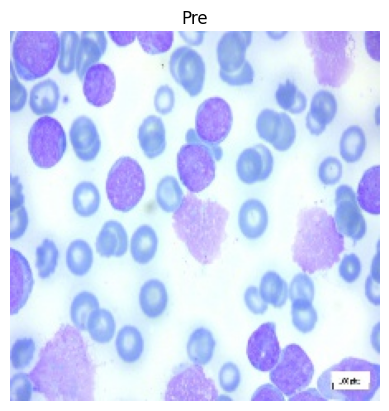

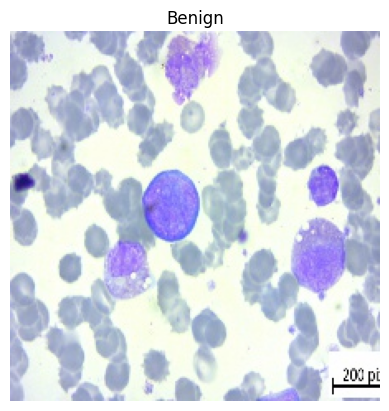

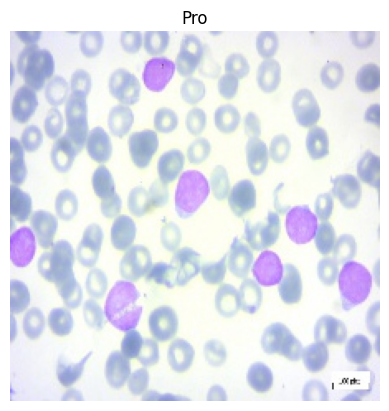

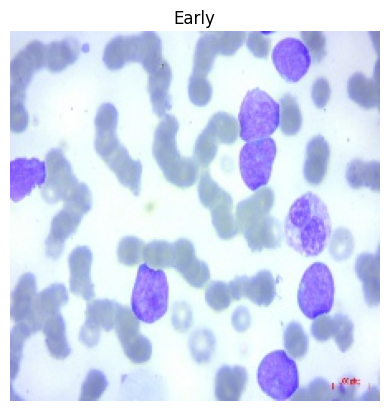

In [28]:
import matplotlib.pyplot as plt

for category in categories:
    path = os.path.join(dataset_path, category)
    img = os.listdir(path)[0]
    img_path = os.path.join(path, img)

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.imshow(image)
    plt.title(category)
    plt.axis('off')
    plt.show()

Images were loaded from class folders, resized for uniformity, converted into numerical feature vectors, and labeled for supervised learning.

In [29]:
import os

for category in categories:
    path = os.path.join(dataset_path, category)
    label = categories.index(category)

    for img in os.listdir(path):
        try:
            img_path = os.path.join(path, img)
            image = cv2.imread(img_path)

            if image is None:
                continue

            image = cv2.resize(image, (64, 64))   # resize for uniformity
            data.append(image.flatten())          # convert to 1D vector
            labels.append(label)

        except Exception as e:
            pass

Convert into NumPy Arrays.

In [30]:
X = np.array(data)
y = np.array(labels)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (3256, 12288)
Shape of y: (3256,)


Data normalization.

In [31]:
X = X / 255.0

Dividing data into training and testing.

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

MODEL 1: Decision Tree

In [20]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

print("Decision Tree Accuracy:", dt.score(X_test, y_test))

Decision Tree Accuracy: 0.7607361963190185


MMODEL 2: Random Forest

In [21]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

print("Random Forest Accuracy:", rf.score(X_test, y_test))

Random Forest Accuracy: 0.8957055214723927


MMODEL 3: K Nearest Neighbor

In [22]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print("KNN Accuracy:", knn.score(X_test, y_test))

KNN Accuracy: 0.5598159509202454


Accuracy of all models.

In [34]:
print("Decision Tree:", dt.score(X_test, y_test))
print("Random Forest:", rf.score(X_test, y_test))
print("KNN:", knn.score(X_test, y_test))

Decision Tree: 0.7607361963190185
Random Forest: 0.8957055214723927
KNN: 0.5598159509202454


Confusion matrix for random forest model (Best Model)

In [35]:
from sklearn.metrics import confusion_matrix

y_pred = rf.predict(X_test)
print(confusion_matrix(y_test, y_pred))

[[199   0   2  19]
 [  0  51  19  25]
 [  0   0 152   0]
 [  0   3   0 182]]


Classification Reort of random forest (Tells about thr detailed metrics)

In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95       220
           1       0.94      0.54      0.68        95
           2       0.88      1.00      0.94       152
           3       0.81      0.98      0.89       185

    accuracy                           0.90       652
   macro avg       0.91      0.86      0.86       652
weighted avg       0.91      0.90      0.89       652



In [65]:
from google.colab import files
files.upload()

Saving test.jpeg to test (2).jpeg


{'test (2).jpeg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xe2\x01\xd8ICC_PROFILE\x00\x01\x01\x00\x00\x01\xc8\x00\x00\x00\x00\x040\x00\x00mntrRGB XYZ \x07\xe0\x00\x01\x00\x01\x00\x00\x00\x00\x00\x00acsp\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x00\x00\xf6\xd6\x00\x01\x00\x00\x00\x00\xd3-\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\tdesc\x00\x00\x00\xf0\x00\x00\x00$rXYZ\x00\x00\x01\x14\x00\x00\x00\x14gXYZ\x00\x00\x01(\x00\x00\x00\x14bXYZ\x00\x00\x01<\x00\x00\x00\x14wtpt\x00\x00\x01P\x00\x00\x00\x14rTRC\x00\x00\x01d\x00\x00\x00(gTRC\x00\x00\x01d\x00\x00\x00(bTRC\x00\x00\x01d\x00\x00\x00(cprt\x00\x00\x01\x8c\x00\x00\x00<mluc\x00\x00\x00\x00\x00\x00\x00\x01\x00\x00\x00\x0cenUS\x00\x00\x00\x08\x00\x00\x00\x1c\x00s\x00R\x00G\x00BXY

In [66]:
print(os.listdir())

['.config', 'dataset', 'archive (2).zip', 'test.jpeg', 'test (2).jpeg', 'test (1).jpeg', 'sample_data']


In [72]:
import os
print(os.path.exists("test (2).jpeg"))

True


In [73]:
import cv2

image = cv2.imread("test (2).jpeg")
print(image)

[[[241 220 219]
  [240 220 219]
  [240 220 219]
  ...
  [203 185 186]
  [207 189 190]
  [209 191 192]]

 [[240 219 218]
  [240 220 219]
  [240 220 219]
  ...
  [205 187 188]
  [210 192 193]
  [212 194 195]]

 [[240 218 220]
  [239 218 220]
  [240 219 221]
  ...
  [209 191 192]
  [213 197 198]
  [215 199 200]]

 ...

 [[249 223 223]
  [250 226 226]
  [251 231 230]
  ...
  [216 190 190]
  [223 191 192]
  [238 204 204]]

 [[248 216 217]
  [250 222 222]
  [251 227 227]
  ...
  [223 192 193]
  [223 189 189]
  [238 202 202]]

 [[244 210 211]
  [248 217 218]
  [251 225 225]
  ...
  [211 180 181]
  [223 189 189]
  [238 202 202]]]


In [69]:
if image is None:
    print("Image load nahi hui")
else:
    image = cv2.resize(image, (64, 64))
    print("Resize successful")

Resize successful


In [74]:
import cv2
import numpy as np

# path of new image
img_path = "test (2).jpeg"

# read image
image = cv2.imread(img_path)

# resize (same as training)
image = cv2.resize(image, (64, 64))

# flatten
image = image.flatten()

# normalize
image = image / 255.0

# reshape (VERY IMPORTANT)
image = image.reshape(1, -1)

# predict using model (example: Random Forest)
prediction = rf.predict(image)

print("Predicted Class:", prediction[0])

Predicted Class: 2


In [75]:
print("Predicted Label:", categories[prediction[0]])

Predicted Label: Pro
